In [1]:
# ============================================================
# Script 4.39 (Updated): Variational Quantum Real Time Evolution
# ============================================================
# PERUBAHAN QISKIT 2.x:
# - qiskit_algorithms adalah package TERPISAH, install: pip install qiskit-algorithms
# - Estimator V1 (qiskit.primitives.Estimator) DEPRECATED
#   → gunakan StatevectorEstimator (V2) untuk simulasi lokal
# - Interface Estimator V2 berbeda: run([(circuit, observable, params)])

# Install yang diperlukan (jalankan sekali):
# pip install qiskit-algorithms

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import ExcitationPreserving
from qiskit.primitives import StatevectorEstimator  # V2, pengganti Estimator V1

# qiskit_algorithms: package terpisah, pastikan sudah install
from qiskit_algorithms import VarQRTE, TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import RealMcLachlanPrinciple

# --- Definisi Hamiltonian ---
# H = 0.5·ZI + 0.5·IZ + 0.2·XX
# Sistem 2 qubit sederhana untuk demonstrasi
hamiltonian = SparsePauliOp.from_list([("ZI", 0.5), ("IZ", 0.5), ("XX", 0.2)])

# --- Setup Estimator V2 ---
# StatevectorEstimator: exact simulator, tidak perlu shots untuk simulasi ideal
# Tapi untuk mendekati perilaku hardware (finite shots), bisa set shots
estimator = StatevectorEstimator()
# Jika ingin finite shots (lebih realistis):
# estimator = StatevectorEstimator(default_precision=1/np.sqrt(1024))

# --- Parameter waktu ---
total_time         = 5.0
evolution_timestep = 0.2

# --- State awal: |10⟩ (qubit-0 di spin-up, qubit-1 di spin-down) ---
def make_init_circuit():
    """Circuit untuk menyiapkan state awal |10⟩."""
    qc = QuantumCircuit(2)
    qc.x(0)   # flip qubit-0: |0⟩ → |1⟩
    return qc

init_circ = make_init_circuit()
print("Initial state circuit:")
print(init_circ.draw(output='text'))

# --- Definisi Ansatz ---
# ExcitationPreserving: ansatz yang mempertahankan jumlah excitations
# Analogi: seperti memilih basis fungsi untuk ekspansi — 
# hanya bisa merepresentasikan state dengan jumlah 'partikel' yang sama
# 
# CATATAN KRITIS: untuk Hamiltonian XX, ini mungkin bukan pilihan optimal
# karena XX bisa mengubah excitation number

base_ansatz = ExcitationPreserving(
    num_qubits=2,
    entanglement='linear',
    reps=1
)
# Gabungkan: init_state + ansatz
# Penting: pada t=0, ansatz harus = identitas → semua params = 0
full_ansatz = init_circ.compose(base_ansatz)

print(f"\nAnsatz memiliki {full_ansatz.num_parameters} parameter")
print(full_ansatz.decompose().draw(output='text'))

# --- Verifikasi: pastikan ansatz(params=0) = init_state ---
params_zero = np.zeros(full_ansatz.num_parameters)
ansatz_at_zero = full_ansatz.assign_parameters(params_zero)

from qiskit.quantum_info import Statevector
sv_zero = Statevector(ansatz_at_zero)
print(f"\nState ansatz(θ=0): {np.round(np.array(sv_zero), 4)}")
print("Harapan: harus = state |10⟩ = [0, 0, 1, 0]")
# Jika tidak sama, ansatz perlu disesuaikan!

Initial state circuit:
     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
          

Ansatz memiliki 5 parameter


/tmp/ipykernel_3885028/789447477.py:58: DeprecationWarning: The class ``qiskit.circuit.library.n_local.excitation_preserving.ExcitationPreserving`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.excitation_preserving instead.
  base_ansatz = ExcitationPreserving(


     ┌──────────┐┌──────────┐┌────────────────────┐┌──────────┐
q_0: ┤ U(π,0,π) ├┤ Rz(θ[0]) ├┤0                   ├┤ Rz(θ[3]) ├
     ├──────────┤└──────────┘│  (XX+YY)(2*θ[2],0) │├──────────┤
q_1: ┤ Rz(θ[1]) ├────────────┤1                   ├┤ Rz(θ[4]) ├
     └──────────┘            └────────────────────┘└──────────┘

State ansatz(θ=0): [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Harapan: harus = state |10⟩ = [0, 0, 1, 0]


In [2]:
# --- Menjalankan VarQRTE ---
# McLachlan variational principle: turunkan parameter evolution
# dari minimisasi ||( ∂/∂t + iH )|ψ(θ)⟩||
var_principle = RealMcLachlanPrinciple()

# Initial parameters: semua nol (ansatz = identitas)
initial_params = np.zeros(full_ansatz.num_parameters)

# Definisi masalah evolusi
evolution_problem = TimeEvolutionProblem(
    hamiltonian=hamiltonian,
    time=total_time,
    # Bisa tambahkan observables untuk track selama evolusi:
    # aux_operators={"energy": hamiltonian}
)

# Inisialisasi VarQRTE
# num_timesteps: jumlah langkah dt = total_time / num_timesteps
n_timesteps = int(total_time / evolution_timestep)  # = 25
qrte = VarQRTE(
    ansatz=full_ansatz,
    initial_parameters=initial_params,
    variational_principle=var_principle,
    estimator=estimator,
    num_timesteps=n_timesteps,
    ode_solver='RK45'  # Qiskit 2.x: bisa eksplisit tentukan ODE solver
)

print(f"Menjalankan VarQRTE: {n_timesteps} langkah, total_time={total_time}")
result = qrte.evolve(evolution_problem)

# Ambil parameter akhir dari trajektori
params_trajectory = result.parameter_values
print(f"Jumlah snapshot parameter: {len(params_trajectory)}")
print(f"Parameter akhir (t={total_time}): {np.round(params_trajectory[-1], 4)}")

# --- Rekonstruksi state pada t = total_time ---
evolved_circuit = full_ansatz.assign_parameters(params_trajectory[-1])
sv_final = Statevector(evolved_circuit)
print(f"\nState akhir |ψ(t={total_time})⟩:")
print(np.round(np.array(sv_final), 4))
print(evolved_circuit.decompose().draw(output='text'))

Menjalankan VarQRTE: 25 langkah, total_time=5.0
Jumlah snapshot parameter: 7
Parameter akhir (t=5.0): [-0.  0.  1.  0. -0.]

State akhir |ψ(t=5.0)⟩:
[ 0.    +0.j      0.5403-0.j     -0.    -0.8415j  0.    +0.j    ]
     ┌──────────┐┌───────┐┌───────────────┐┌───────┐
q_0: ┤ U(π,0,π) ├┤ Rz(0) ├┤0              ├┤ Rz(0) ├
     └┬───────┬─┘└───────┘│  (XX+YY)(2,0) │├───────┤
q_1: ─┤ Rz(0) ├───────────┤1              ├┤ Rz(0) ├
      └───────┘           └───────────────┘└───────┘


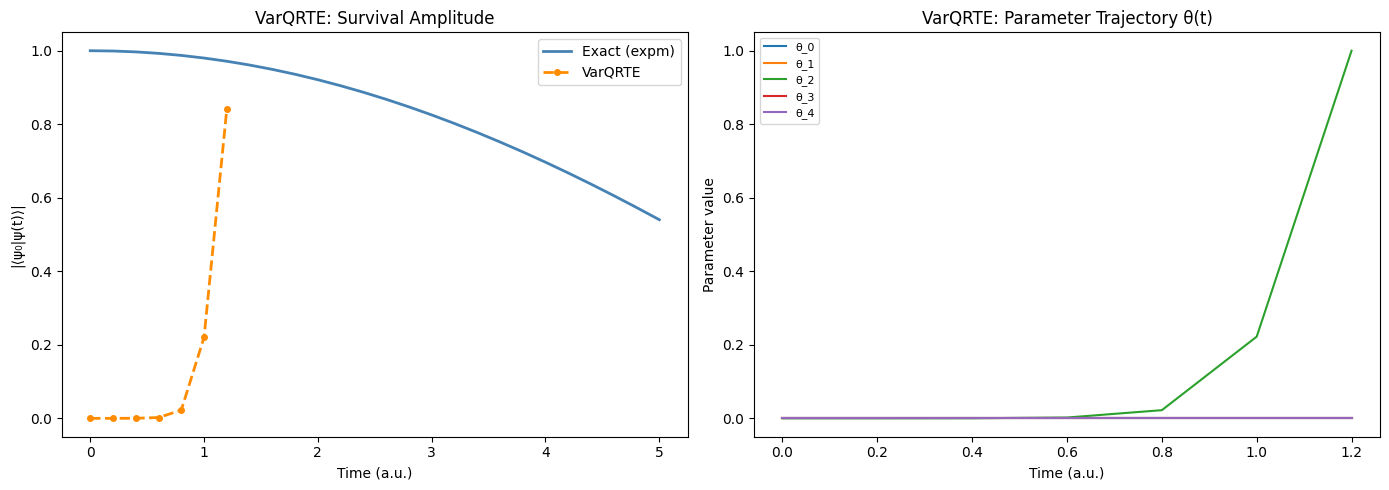

In [3]:
# --- Benchmark: bandingkan dengan evolusi eksak (matrix exponentiation) ---
from scipy.linalg import expm

# Konversi Hamiltonian ke matrix
H_matrix = hamiltonian.to_matrix()

# State awal |10⟩ = index 2 dalam konvensi Qiskit (little-endian)
psi_init_exact = np.zeros(4, dtype=complex)
psi_init_exact[2] = 1.0  # |10⟩

time_points = np.linspace(0, total_time, n_timesteps + 1)
survival_varqrte = []
survival_exact   = []

for i, t_val in enumerate(time_points):
    # Exact evolution
    U_exact   = expm(-1j * H_matrix * t_val)
    psi_exact = U_exact @ psi_init_exact
    survival_exact.append(np.abs(np.vdot(psi_init_exact, psi_exact)))

    # VarQRTE evolution (menggunakan parameter snapshot)
    if i < len(params_trajectory):
        circ_t = full_ansatz.assign_parameters(params_trajectory[i])
        sv_t   = np.array(Statevector(circ_t))
        survival_varqrte.append(np.abs(np.vdot(psi_init_exact, sv_t)))

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival amplitude
ax = axes[0]
ax.plot(time_points, survival_exact,              '-',  lw=2, label='Exact (expm)',  color='steelblue')
ax.plot(time_points[:len(survival_varqrte)],
        survival_varqrte, '--o', lw=2, ms=4, label='VarQRTE', color='darkorange')
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('|⟨ψ₀|ψ(t)⟩|')
ax.set_title('VarQRTE: Survival Amplitude')
ax.legend()

# Parameter trajectory
ax = axes[1]
params_arr = np.array(params_trajectory)
for p_idx in range(params_arr.shape[1]):
    ax.plot(time_points[:len(params_trajectory)],
            params_arr[:, p_idx], label=f'θ_{p_idx}')
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Parameter value')
ax.set_title('VarQRTE: Parameter Trajectory θ(t)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()